In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil
import pandas as pd
import seaborn as sns
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. SETUP & DRIVE MOUNT
# ==========================================
print("Step 1: Mounting Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURATION PATHS ---
# Input Zip Location
ZIP_PATH = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Data Set/thalassemia_dataset_new.zip'

# Output Directory (For saving results)
RESULTS_DIR = '/content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results'

# Create Results Directory if it doesn't exist
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f"Created output directory: {RESULTS_DIR}")
else:
    print(f"Saving results to: {RESULTS_DIR}")

# ==========================================
# 2. DATA EXTRACTION & MERGING
# ==========================================
print("\nStep 2: Extracting and Preparing Data...")

# Unzip to a local temporary folder (Faster than reading from Drive)
LOCAL_DATA_DIR = '/content/dataset/thalassemia_dataset'
if os.path.exists(LOCAL_DATA_DIR):
    shutil.rmtree('/content/dataset') # Clean up old runs

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# --- AUTO-MERGE LOGIC ---
# If "Full Thalassemia" exists, move its contents to "Thalassemia"
thal_path = os.path.join(LOCAL_DATA_DIR, 'Thalassemia')
full_thal_path = os.path.join(LOCAL_DATA_DIR, 'Full Thalassemia') # Check exact name in your zip

if os.path.exists(full_thal_path):
    print("⚠️ Found separate 'Full Thalassemia' folder. Merging it into 'Thalassemia'...")
    if not os.path.exists(thal_path):
        os.makedirs(thal_path)

    # Move files
    for filename in os.listdir(full_thal_path):
        src = os.path.join(full_thal_path, filename)
        dst = os.path.join(thal_path, filename)
        if os.path.isfile(src):
            shutil.move(src, dst)

    # Remove empty folder
    shutil.rmtree(full_thal_path)
    print("✅ Merge complete. All Thalassemia images are now in one folder.")

# Verify folder structure
print(f"Classes found: {os.listdir(LOCAL_DATA_DIR)}")

Step 1: Mounting Google Drive...
Mounted at /content/drive
Saving results to: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results

Step 2: Extracting and Preparing Data...
Classes found: ['Normal', 'Thalassemia']


In [2]:
# ==========================================
# 3. DATA PROCESSING & AUGMENTATION
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

print("\nLoading Training Data...")
train_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

print("\nLoading Validation Data...")
validation_generator = train_datagen.flow_from_directory(
    LOCAL_DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False # IMPORTANT: Don't shuffle for Confusion Matrix/ROC to work correctly
)

# --- CLASS IMBALANCE HANDLING ---
# Calculate weights so the model doesn't favor the majority class
cls_train = train_generator.classes
classes = np.unique(cls_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=cls_train)
class_weights = dict(zip(classes, weights))
print(f"\n⚖️ Class Weights calculated: {class_weights}")


Loading Training Data...
Found 2000 images belonging to 2 classes.

Loading Validation Data...
Found 499 images belonging to 2 classes.

⚖️ Class Weights calculated: {np.int32(0): np.float64(0.8764241893076249), np.int32(1): np.float64(1.1641443538998837)}


In [3]:
# ==========================================
# 4. MODEL BUILDING (ResNet50V2)
# ==========================================
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# ==========================================
# 5. CALLBACKS (SAVING RESULTS)
# ==========================================
# 1. Save Best Model
checkpoint_path = os.path.join(RESULTS_DIR, 'best_thalassemia_model.keras')
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

# 2. Save Training CSV Log
csv_logger = CSVLogger(os.path.join(RESULTS_DIR, 'training_log.csv'), append=True)

# 3. Reduce Learning Rate if stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

callbacks_list = [checkpoint, csv_logger, reduce_lr]

In [5]:
# ==========================================
# 6. TRAIN
# ==========================================
print("\n🚀 Starting Training...")
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_list
)


🚀 Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7341 - loss: 0.5365
Epoch 1: val_accuracy improved from -inf to 0.89379, saving model to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/best_thalassemia_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 403s 6s/step - accuracy: 0.7351 - loss: 0.5349 - val_accuracy: 0.8938 - val_loss: 0.2529 - learning_rate: 1.0000e-04
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8746 - loss: 0.2862
Epoch 2: val_accuracy improved from 0.89379 to 0.92585, saving model to /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/best_thalassemia_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 434s 6s/step - accuracy: 0.8748 - loss: 0.2860 - val_accuracy: 0.9259 - val_loss: 0.1846 - learning_rate: 1.0000e-04
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8955 - loss: 0.2373
Epoch 3: val_accuracy did not improve from 0.92585
63/63 ━━━━━━━━━━━━━━━━━━━━ 391s 6s/step - accuracy: 0.895

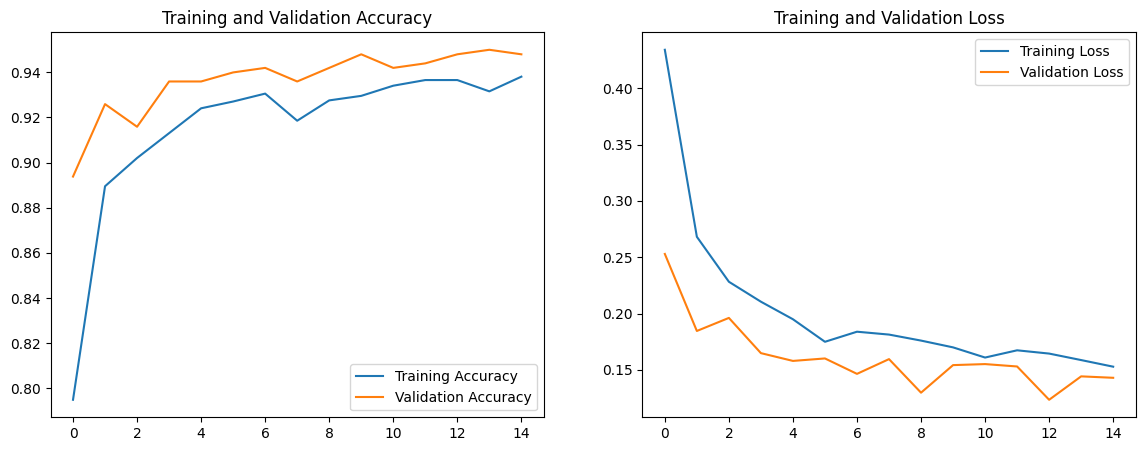

✅ Accuracy chart saved to: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/accuracy_loss_chart.png

Generating Confusion Matrix & ROC (This takes a moment)...
16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step


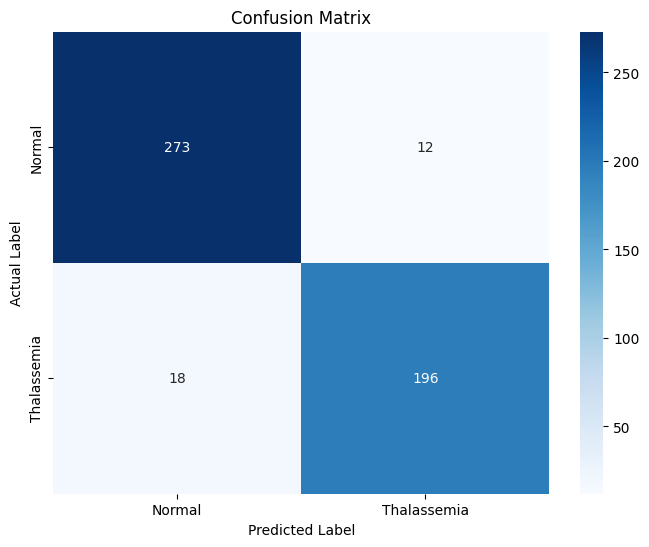

✅ Confusion Matrix saved to: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/confusion_matrix.png


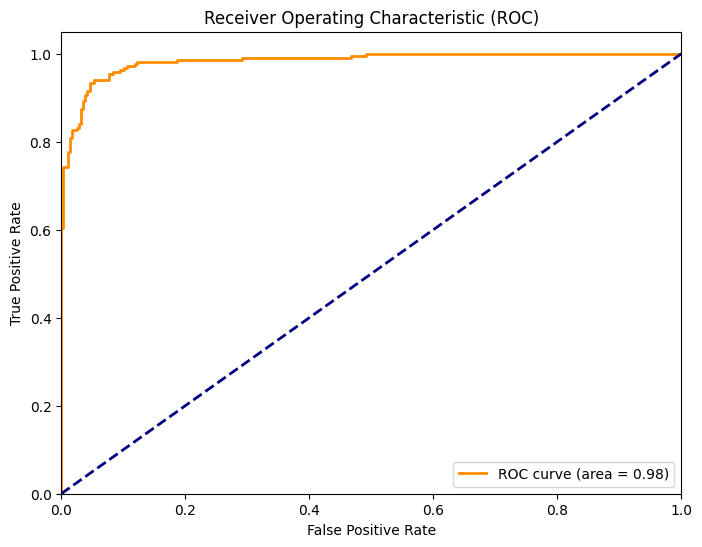

✅ ROC Curve saved to: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/roc_curve.png

🎉 ALL DONE! Check your Google Drive folder 'Training Results' for the files.


In [6]:
# ==========================================
# 7. METRICS & PLOTTING (SAVING TO DRIVE)
# ==========================================

# A. Accuracy & Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# Save Chart
chart_path = os.path.join(RESULTS_DIR, 'accuracy_loss_chart.png')
plt.savefig(chart_path)
plt.show()
print(f"✅ Accuracy chart saved to: {chart_path}")

# --- PREDICTIONS FOR CONFUSION MATRIX ---
print("\nGenerating Confusion Matrix & ROC (This takes a moment)...")
# Get True Labels
y_true = validation_generator.classes
# Get Predicted Probabilities
y_pred_prob = model.predict(validation_generator)
# Convert probabilities to binary predictions (Threshold 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# B. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path)
plt.show()
print(f"✅ Confusion Matrix saved to: {cm_path}")

# C. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
roc_path = os.path.join(RESULTS_DIR, 'roc_curve.png')
plt.savefig(roc_path)
plt.show()
print(f"✅ ROC Curve saved to: {roc_path}")

print("\n🎉 ALL DONE! Check your Google Drive folder 'Training Results' for the files.")

Loading model from: /content/drive/MyDrive/Hemora Research Thalassemia Component/Training Results/best_thalassemia_model.keras
✅ Model loaded successfully!

Upload a FULL microscope slide image (.jpg/.png):


Saving c0222234-800px-wm.jpg to c0222234-800px-wm.jpg
Processing image: c0222234-800px-wm.jpg...
Found 90 potential objects. Analyzing...


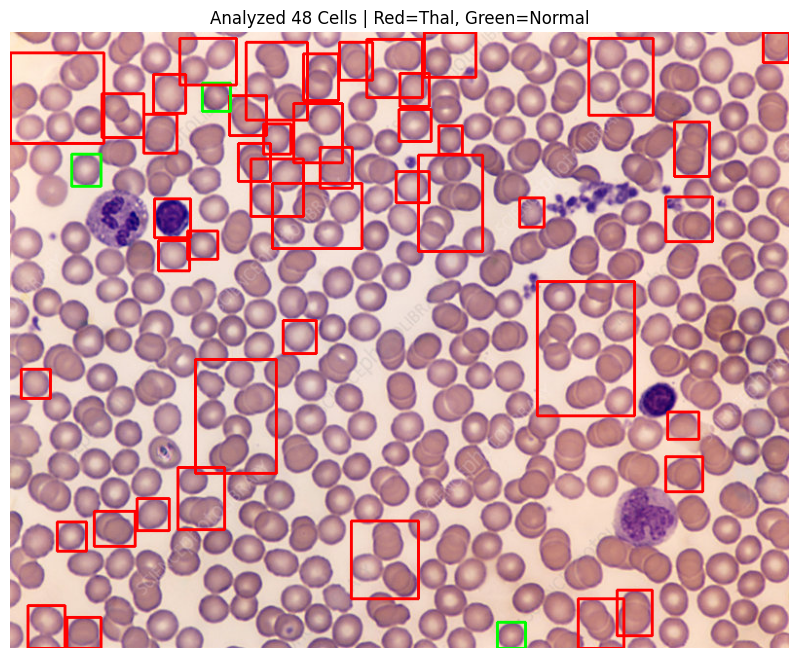

Total Cells Analyzed: 48
Normal Cells (Green): 3
Thalassemia Cells (Red): 45
Thalassemia Ratio: 93.8%
>>> DIAGNOSIS: POSITIVE for Thalassemia Morphologies


In [9]:
# ==========================================
# FINAL STEP: FULL BLOOD SMEAR ANALYSIS PIPELINE
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from google.colab import files

# --- CONFIGURATION ---
# We load the best model saved in Step 5/6
MODEL_PATH = os.path.join(RESULTS_DIR, 'best_thalassemia_model.keras')
IMG_SIZE = (224, 224)

# Colors for bounding boxes (BGR format for OpenCV)
COLOR_NORMAL = (0, 255, 0)   # Green
COLOR_THAL = (0, 0, 255)     # Red
THRESHOLD_SCORE = 0.5        # Confidence threshold

print(f"Loading model from: {MODEL_PATH}")
try:
    pipeline_model = load_model(MODEL_PATH)
    print("✅ Model loaded successfully!")
except:
    print("⚠️ Error loading model. Make sure the training finished and saved the .keras file.")
    raise SystemExit

def preprocess_for_model(cell_crop_bgr):
    """Takes a BGR crop, converts to RGB, resizes, and normalizes"""
    cell_rgb = cv2.cvtColor(cell_crop_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(cell_rgb, IMG_SIZE)
    img_array = img_to_array(resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    return img_array

def analyze_full_smear(image_path, model):
    print(f"Processing image: {image_path}...")
    original_img = cv2.imread(image_path)
    if original_img is None:
        print("Error: Could not read image.")
        return
    output_img = original_img.copy()

    # 1. Segmentation (Find cells)
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh_val, thresholded_img = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresholded_img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Found {len(contours)} potential objects. Analyzing...")

    thal_count = 0
    normal_count = 0
    cells_analyzed = 0

    # 2. Analyze each cell
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(cnt)

        # Filter out noise (too small) or clumps (too big)
        # Adjust 'area' limits if your boxes are too small or missing cells
        if area < 500 or area > 6000:
            continue
        if aspect_ratio < 0.6 or aspect_ratio > 1.4:
            continue

        cells_analyzed += 1

        # Crop and Predict
        pad = 5
        y1, y2 = max(0, y-pad), min(original_img.shape[0], y+h+pad)
        x1, x2 = max(0, x-pad), min(original_img.shape[1], x+w+pad)
        cell_crop = original_img[y1:y2, x1:x2]

        if cell_crop.size == 0: continue

        processed_cell = preprocess_for_model(cell_crop)
        prediction = model.predict(processed_cell, verbose=0)
        score = prediction[0][0]

        # Determine Class (Assumes: 0=Normal, 1=Thalassemia)
        # You can verify this by checking 'train_generator.class_indices'
        if score > THRESHOLD_SCORE:
            color = COLOR_THAL # Red
            thal_count += 1
        else:
            color = COLOR_NORMAL # Green
            normal_count += 1

        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

    # 3. Display Results
    output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(output_rgb)
    plt.axis('off')
    plt.title(f"Analyzed {cells_analyzed} Cells | Red=Thal, Green=Normal")
    plt.show()

    # 4. Final Report
    print("="*40)
    print(f"Total Cells Analyzed: {cells_analyzed}")
    print(f"Normal Cells (Green): {normal_count}")
    print(f"Thalassemia Cells (Red): {thal_count}")

    if cells_analyzed > 0:
        ratio = thal_count / cells_analyzed
        print(f"Thalassemia Ratio: {ratio*100:.1f}%")
        if ratio > 0.05: # Threshold: If >5% cells are bad, flag the patient
            print(">>> DIAGNOSIS: POSITIVE for Thalassemia Morphologies")
        else:
            print(">>> DIAGNOSIS: NEGATIVE (Normal)")
    print("="*40)

# --- RUN PIPELINE ---
print("\nUpload a FULL microscope slide image (.jpg/.png):")
uploaded_full = files.upload()

if len(uploaded_full) > 0:
    full_image_path = list(uploaded_full.keys())[0]
    analyze_full_smear(full_image_path, pipeline_model)
else:
    print("No file uploaded.")